# Zomato data analysis project


## importing libraries 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

##### load the dataset

In [3]:
# creat the data frame 
df=pd.read_csv("Zomato data .csv")

print(df.head(5))

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


# convert the data type of column -rate 

In [4]:
def handle_rate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)
df['rate'] =df['rate'].apply(handle_rate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# Type of Restaurant

- Question1= what type of restaurant do the majority of customers order from?

Text(0.5, 0, 'type of restaurant')

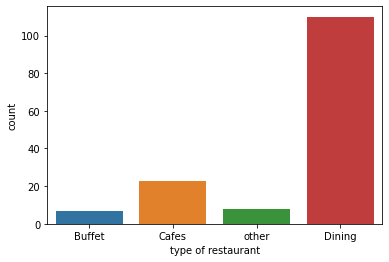

In [6]:
sns.countplot(x=df['listed_in(type)']) 
plt.xlabel('type of restaurant')

- conclusion= majority of the restaurant falls in dinning category

In [7]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


# Votes of each type of restaurant

- Question2- How many votes has each type of restaurant received from customers?

Text(0, 0.5, 'votes')

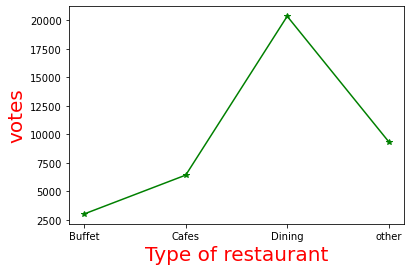

In [14]:
grouped_data= df.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes': grouped_data})
plt.plot(result,c='green',marker='*')
plt.xlabel('Type of restaurant', c="red",size=20)
plt.ylabel('votes',c='red',size=20)

- conclusion - dining restaurants has recieved maximum votes

# Rating of the restaurant 

- Question 3- what are the rating that the majority of restaurant have received ?

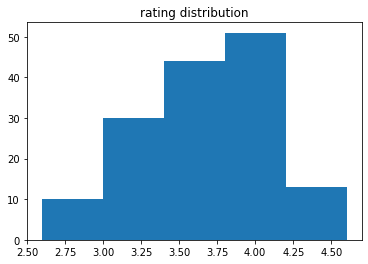

In [17]:
plt.hist(df['rate'], bins=5)
plt.title("rating distribution")
plt.show()

- conclusion -  the majority restaurant receives rating from 3.5 to 4 

# Average spending by couples

- Question 4- Zomato has observed that most couples order mst of their food online. what is their average spending on each other 

<AxesSubplot:xlabel='approx_cost(for two people)', ylabel='count'>

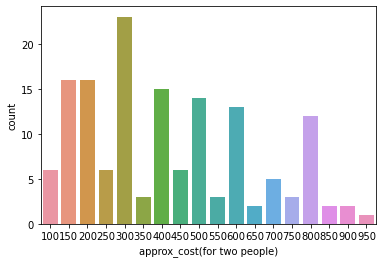

In [20]:
couple_data= df['approx_cost(for two people)']
sns.countplot(x=couple_data)

- conclusion the majority of couples prefer restaurant with an approximate cost of 300 rupees 

# mode that has received max rating

- Question5- which mode (online r offline )has received mmax rating?

In [22]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<AxesSubplot:xlabel='online_order', ylabel='rate'>

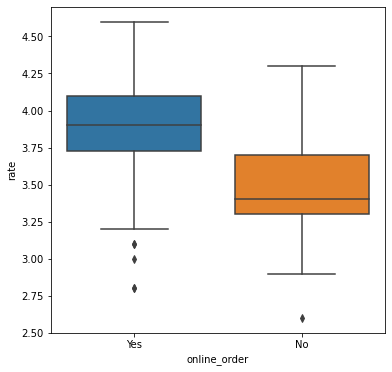

In [23]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order', y= 'rate',data=df)

- conclusion - offline order received lower rating in comparision to online order 

- Question 6 -which type of restaurant received more offline orders, so taht Zomato can provise customer with some good offers? 

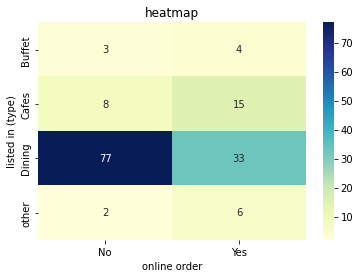

In [33]:
pivot_table =df.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table,annot=True,cmap="YlGnBu",fmt='d')
plt.title("heatmap")
plt.xlabel("online order")
plt.ylabel('listed in (type)')
plt.show()


#  CONCLUSION:Dining restaurant primarily accept offline orders whereas cafe primarily receives online orders. This suggests that clients prefer placed orders in person at restaurant ,but prefer online ordering at cafes.